In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from pathlib import Path

plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

CLEAN_FILE = Path('../data/clean/gdelt_benin_clean.parquet')

QUADCLASS_LABELS = {
    1: 'Coopération Verbale',
    2: 'Coopération Matérielle',
    3: 'Conflit Verbal',
    4: 'Conflit Matériel'
}

print('✓ Imports OK')

✓ Imports OK


In [3]:
df = pd.read_parquet(CLEAN_FILE)
print(f'Lignes   : {len(df):,}')
print(f'Période  : {df["SQLDATE"].min().date()} → {df["SQLDATE"].max().date()}')
df.head(3)

Lignes   : 22,778
Période  : 2025-04-26 → 2026-04-26


,GLOBALEVENTID,SQLDATE,MonthYear,Year,FractionDate,Actor1Code,Actor1Name,Actor1CountryCode,Actor1KnownGroupCode,Actor1EthnicCode,...,ActionGeo_ADM1Code,ActionGeo_ADM2Code,ActionGeo_Lat,ActionGeo_Long,ActionGeo_FeatureID,DATEADDED,SOURCEURL,year,month,week
0,1248558842,2025-06-09,202506,2025,2025.4356,BEN,COTONOU,BEN,NaN,NaN,...,BN,NaN,9.5,2.25,BN,20250609020000,https://english.news.cn/20250609/833e6be5b34f4...,2025,6,24
1,1248561281,2025-06-09,202506,2025,2025.4356,NGA,BENIN CITY,NGA,NaN,NaN,...,BN,NaN,9.5,2.25,BN,20250609023000,https://punchng.com/ndlea-intercepts-drugs-dis...,2025,6,24
2,1248560915,2025-06-09,202506,2025,2025.4356,BEN,BENIN,BEN,NaN,NaN,...,BN,NaN,9.5,2.25,BN,20250609023000,https://punchng.com/ndlea-intercepts-drugs-dis...,2025,6,24


In [4]:
df_conflict  = df[df['QuadClass'].isin([3, 4])].copy()
df_high_risk = df[df['GoldsteinScale'] < -5].copy()
total        = len(df)

print('═' * 50)
print('  VUE D\'ENSEMBLE SÉCURITAIRE')
print('═' * 50)
print(f'  Total événements        : {total:,}')
print(f'  Événements conflictuels : {len(df_conflict):,}  ({len(df_conflict)/total*100:.1f}%)')
print(f'  Haut risque (GS < -5)   : {len(df_high_risk):,}  ({len(df_high_risk)/total*100:.1f}%)')
print(f'  GoldsteinScale moyen    : {df["GoldsteinScale"].mean():.3f}')
print(f'  AvgTone moyen           : {df["AvgTone"].mean():.3f}')
print('═' * 50)

══════════════════════════════════════════════════
  VUE D'ENSEMBLE SÉCURITAIRE
══════════════════════════════════════════════════
  Total événements        : 22,778
  Événements conflictuels : 6,081  (26.7%)
  Haut risque (GS < -5)   : 2,370  (10.4%)
  GoldsteinScale moyen    : 0.501
  AvgTone moyen           : -1.612
══════════════════════════════════════════════════


gros poinst pour amrquer les  evenements 
calculer l'indice 


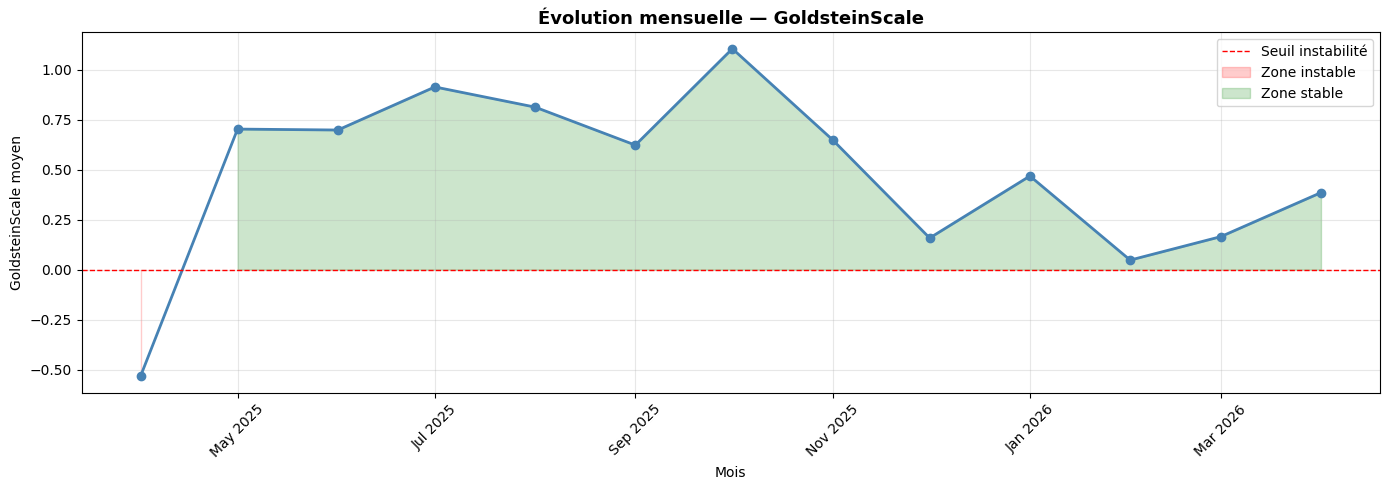

In [5]:
monthly = (
    df.groupby(df['SQLDATE'].dt.to_period('M'))['GoldsteinScale']
    .mean().reset_index()
)
monthly['SQLDATE'] = monthly['SQLDATE'].dt.to_timestamp()

fig, ax = plt.subplots()
ax.plot(monthly['SQLDATE'], monthly['GoldsteinScale'], marker='o', color='steelblue', linewidth=2)
ax.axhline(0, color='red', linestyle='--', linewidth=1, label='Seuil instabilité')
ax.fill_between(monthly['SQLDATE'], monthly['GoldsteinScale'], 0,
                where=monthly['GoldsteinScale'] < 0, alpha=0.2, color='red', label='Zone instable')
ax.fill_between(monthly['SQLDATE'], monthly['GoldsteinScale'], 0,
                where=monthly['GoldsteinScale'] >= 0, alpha=0.2, color='green', label='Zone stable')
ax.set_title('Évolution mensuelle — GoldsteinScale', fontsize=13, fontweight='bold')
ax.set_xlabel('Mois')
ax.set_ylabel('GoldsteinScale moyen')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xticks(rotation=45)
ax.legend()
plt.tight_layout()
plt.savefig('../data/clean/goldstein_mensuel.png', dpi=150)
plt.show()

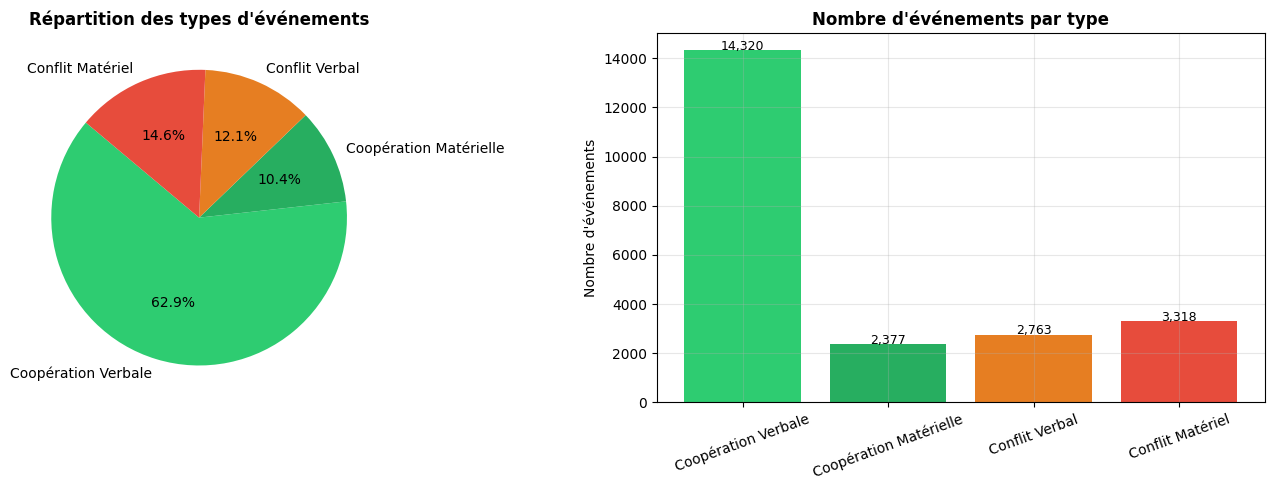

In [6]:
qc = df['QuadClass'].value_counts().sort_index()
qc.index = [QUADCLASS_LABELS.get(i, str(i)) for i in qc.index]
colors = ['#2ecc71', '#27ae60', '#e67e22', '#e74c3c']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.pie(qc, labels=qc.index, autopct='%1.1f%%', colors=colors, startangle=140)
ax1.set_title('Répartition des types d\'événements', fontweight='bold')
bars = ax2.bar(qc.index, qc.values, color=colors)
ax2.set_title('Nombre d\'événements par type', fontweight='bold')
ax2.set_ylabel('Nombre d\'événements')
plt.xticks(rotation=20)
for bar, val in zip(bars, qc.values):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
             f'{val:,}', ha='center', fontsize=9)
plt.tight_layout()
plt.savefig('../data/clean/quadclass_repartition.png', dpi=150)
plt.show()

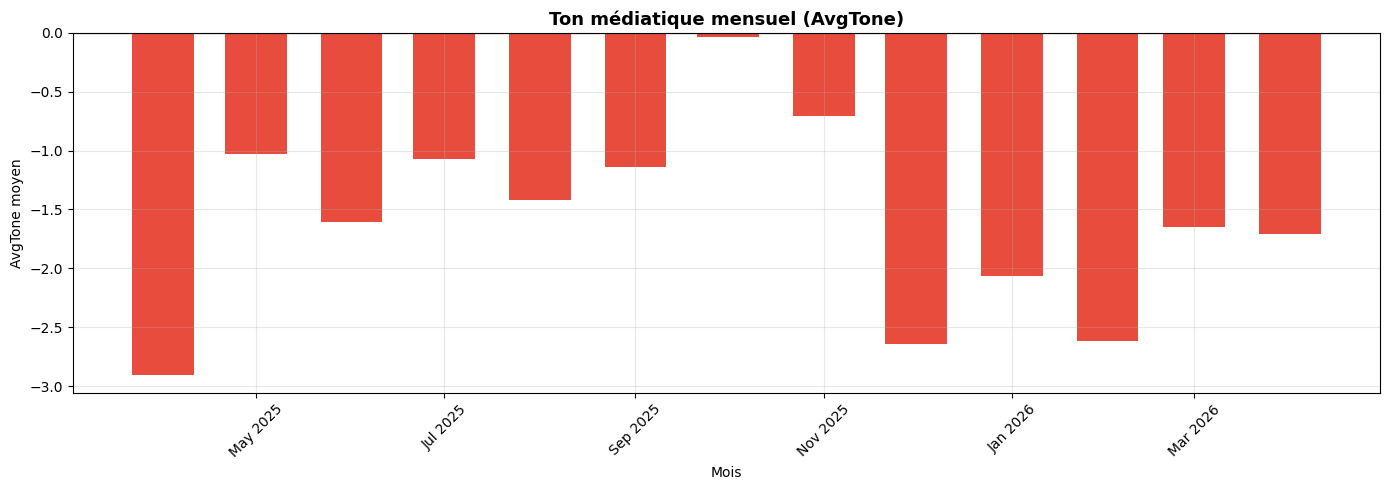

In [7]:
monthly_tone = (
    df.groupby(df['SQLDATE'].dt.to_period('M'))['AvgTone']
    .mean().reset_index()
)
monthly_tone['SQLDATE'] = monthly_tone['SQLDATE'].dt.to_timestamp()

fig, ax = plt.subplots()
ax.bar(monthly_tone['SQLDATE'], monthly_tone['AvgTone'],
       color=['#e74c3c' if v < 0 else '#2ecc71' for v in monthly_tone['AvgTone']], width=20)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_title('Ton médiatique mensuel (AvgTone)', fontsize=13, fontweight='bold')
ax.set_xlabel('Mois')
ax.set_ylabel('AvgTone moyen')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../data/clean/avgtone_mensuel.png', dpi=150)
plt.show()

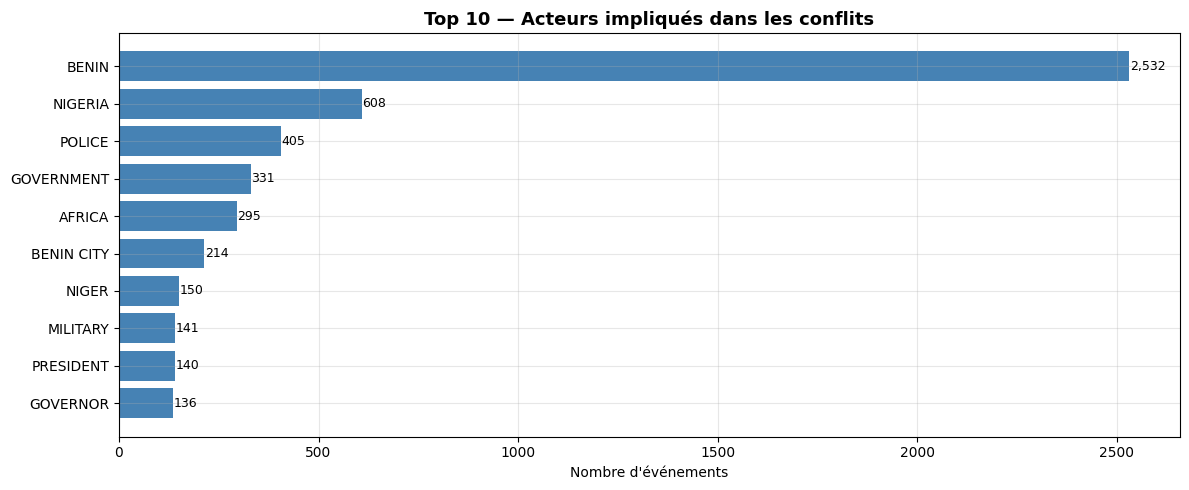

In [8]:
actors = pd.concat([df_conflict['Actor1Name'], df_conflict['Actor2Name']]).value_counts()
actors = actors[actors.index != 'Unknown'].head(10)

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.barh(actors.index[::-1], actors.values[::-1], color='steelblue')
ax.set_title('Top 10 — Acteurs impliqués dans les conflits', fontsize=13, fontweight='bold')
ax.set_xlabel('Nombre d\'événements')
for bar, val in zip(bars, actors.values[::-1]):
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
            f'{val:,}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('../data/clean/top10_acteurs.png', dpi=150)
plt.show()

In [9]:
summary = df.groupby(df['SQLDATE'].dt.to_period('M')).agg(
    total_evenements = ('GLOBALEVENTID', 'count'),
    conflits         = ('QuadClass', lambda x: x.isin([3,4]).sum()),
    goldstein_moy    = ('GoldsteinScale', 'mean'),
    avgtone_moy      = ('AvgTone', 'mean'),
).round(3)

summary['taux_conflit_%'] = (summary['conflits'] / summary['total_evenements'] * 100).round(1)
summary.to_csv('../data/clean/synthese_securite_mensuelle.csv')

print(summary.to_string())
print('\n✓ Synthèse sauvegardée')

         total_evenements  conflits  goldstein_moy  avgtone_moy  taux_conflit_%
SQLDATE                                                                        
2025-04               466       161         -0.533       -2.909            34.5
2025-05              1807       462          0.704       -1.026            25.6
2025-06               908       226          0.699       -1.605            24.9
2025-07              2284       524          0.915       -1.074            22.9
2025-08              1516       382          0.814       -1.420            25.2
2025-09              1630       396          0.623       -1.142            24.3
2025-10              1676       332          1.106       -0.032            19.8
2025-11              1789       423          0.650       -0.708            23.6
2025-12              4221      1339          0.158       -2.646            31.7
2026-01              1544       426          0.469       -2.065            27.6
2026-02              1730       513     